# Modelo Bayesiano Presence-Background: Copetón, PM10, NO2 y O3

Este notebook implementa, de punta a punta, una regresión logística Bayesiana para datos presence-background del Copetón (*Zonotrichia capensis*) en Bogotá.

El flujo sigue `presence_only_logic.md`:

1. Simulación y recuperación de parámetros.
2. Carga del dataset limpio `copeton_presence_only_model_ready_pm10_no2_o3.csv`.
3. Estandarización de covariables para muestreo estable con NUTS.
4. Ajuste Bayesiano con 4 cadenas, 20,000 draws y 2,000 tune.
5. Diagnósticos de convergencia.
6. Transformación posterior de coeficientes desde escala estandarizada a unidades originales.

Interpretación clave: los coeficientes representan asociaciones con la intensidad relativa de presencia, no probabilidades absolutas de ocupación.

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
from scipy.special import expit
from scipy.stats import multivariate_normal
from sklearn.metrics import RocCurveDisplay, accuracy_score, auc, roc_curve

RANDOM_SEED = 42
CHAINS = 4
DRAWS = 20_000
TUNE = 2_000
TARGET_ACCEPT = 0.90

COVARIATES = ["pm10_ugm3", "no2_ppb", "o3_ppb"]
COVARIATE_LABELS = {
    "pm10_ugm3": "PM10 (ug/m3)",
    "no2_ppb": "NO2 (ppb)",
    "o3_ppb": "O3 (ppb)",
}

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "04_bayesian_model":
    PROJECT_DIR = BASE_DIR.parent
else:
    PROJECT_DIR = BASE_DIR

DATA_PATH = PROJECT_DIR / "data" / "processed" / "copeton_presence_only_model_ready_pm10_no2_o3.csv"
OUTPUT_DIR = PROJECT_DIR / "04_bayesian_model" / "outputs_pm10_no2_o3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

az.style.use("arviz-darkgrid")
sns.set_context("notebook")

print(f"PyMC: {pm.__version__}")
print(f"ArviZ: {az.__version__}")
print(f"Dataset esperado: {DATA_PATH}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


PyMC: 5.28.4
ArviZ: 0.23.4
Dataset esperado: C:\Users\Miguel Camargo\Desktop\PROYECTOBAYESIANA-COPETON\data\processed\copeton_presence_only_model_ready_pm10_no2_o3.csv


## 1. Simulación: recuperación de parámetros

Primero simulamos datos con una estructura parecida al problema real: contaminantes correlacionados, un enlace logit y una respuesta binaria presence-background. Si el modelo recupera razonablemente los coeficientes verdaderos, validamos que la implementación estadística y computacional está funcionando.

In [2]:
rng = np.random.default_rng(RANDOM_SEED)

n_sim = 1_354
sim_covariates = COVARIATES
n_covs = len(sim_covariates)

# Correlaciones urbanas plausibles: PM10 y NO2 positivas; O3 tiende a moverse en sentido contrario a NO2.
cov_matrix = np.array([
    [1.00,  0.45, -0.10],
    [0.45,  1.00, -0.45],
    [-0.10, -0.45,  1.00],
])

X_sim = multivariate_normal.rvs(
    mean=np.zeros(n_covs),
    cov=cov_matrix,
    size=n_sim,
    random_state=RANDOM_SEED,
)

true_beta_0 = 0.20
true_betas = np.array([
    -0.35,  # PM10: efecto negativo moderado
     0.45,  # NO2: asociación positiva en registros urbanos
    -0.60,  # O3: efecto negativo fuerte
])

eta_sim = true_beta_0 + X_sim @ true_betas
p_sim = expit(eta_sim)
y_sim = rng.binomial(1, p_sim)

print(f"Simulación: {n_sim:,} filas")
print(f"Presencias simuladas: {y_sim.sum():,}")
print(f"Fondos simulados: {len(y_sim) - y_sim.sum():,}")
pd.DataFrame(X_sim, columns=sim_covariates).corr().round(2)

Simulación: 1,354 filas
Presencias simuladas: 777
Fondos simulados: 577


,pm10_ugm3,no2_ppb,o3_ppb
pm10_ugm3,1.00,0.45,-0.06
no2_ppb,0.45,1.00,-0.43
o3_ppb,-0.06,-0.43,1.00


In [3]:
coords_sim = {"covariate": sim_covariates}

with pm.Model(coords=coords_sim) as sim_model:
    X = pm.Data("X", X_sim)
    beta = pm.Normal("beta", mu=0, sigma=1, dims="covariate")
    beta_0 = pm.Normal("beta_0", mu=0, sigma=1)
    eta = beta_0 + pm.math.dot(X, beta)
    psi = pm.Deterministic("psi", pm.math.invlogit(eta))
    obs = pm.Bernoulli("obs", p=psi, observed=y_sim)

    sim_trace = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, beta_0]


Output()

Sampling 4 chains for 2_000 tune and 20_000 draw iterations (8_000 + 80_000 draws total) took 9822 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[pm10_ugm3],-0.317,0.067,-0.450,-0.186,0.0,0.0,66300.0,60693.0,1.0
beta[no2_ppb],0.499,0.076,0.349,0.647,0.0,0.0,61871.0,59967.0,1.0
beta[o3_ppb],-0.558,0.071,-0.699,-0.419,0.0,0.0,68918.0,58691.0,1.0
beta_0,0.332,0.059,0.218,0.450,0.0,0.0,70110.0,57683.0,1.0


C:\Users\Miguel Camargo\AppData\Local\Temp\ipykernel_30312\724404819.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


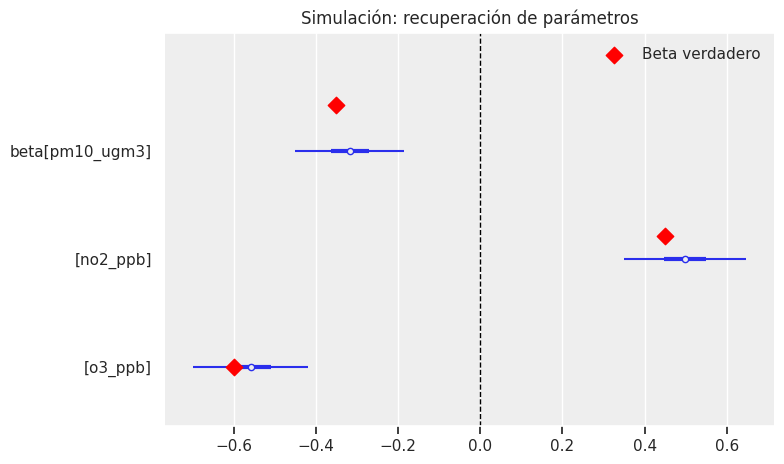

In [7]:
from IPython.display import display

sim_summary = az.summary(sim_trace, var_names=["beta", "beta_0"], hdi_prob=0.95)
display(sim_summary)

fig, ax = plt.subplots(figsize=(8, 4.8))
az.plot_forest(sim_trace, var_names=["beta"], combined=True, hdi_prob=0.95, ax=ax)

ax.scatter(
    true_betas[::-1],
    np.arange(n_covs),
    color="red",
    marker="D",
    s=70,
    label="Beta verdadero",
    zorder=3,
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Simulación: recuperación de parámetros")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_sim_parameter_recovery.png", dpi=180)
plt.show()


## 2. Datos reales model-ready

Cargamos el dataset construido específicamente para modelar: PM10, NO2 y O3 sin nulos. Aquí no hacemos `dropna`; solo verificamos que el archivo cumpla el contrato de datos.

In [8]:
df = pd.read_csv(DATA_PATH)

required_columns = ["y"] + COVARIATES
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

assert df[required_columns].isna().sum().sum() == 0, "El dataset model-ready tiene nulos; regenerar con build_presence_only_modeling_dataset.py"
assert set(df["y"].unique()).issubset({0, 1}), "y debe ser binaria: 0=fondo, 1=presencia"

print(f"Filas: {len(df):,}")
print(df["y"].value_counts().sort_index().rename(index={0: "Fondo", 1: "Presencia"}))
display(df.head())
display(df[COVARIATES].describe().T)

Filas: 1,354
y
Fondo        614
Presencia    740
Name: count, dtype: int64


,y,source,lat,lon,date,matched_hour,month,year,nearest_station,distance_km,quadrature_weight,gbifID,individualCount,pm10_ugm3,no2_ppb,o3_ppb
0,0,background,4.648,-74.140,2022-01-03,6,1,2022.0,Movil Fontibon,2.369032,0.000009,NaN,NaN,53.401932,19.209277,26.652128
1,0,background,4.680,-74.060,2022-01-03,18,1,2022.0,Las Ferias,2.764078,0.000009,NaN,NaN,24.432882,13.058984,27.999449
2,0,background,4.664,-74.052,2022-01-04,11,1,2022.0,Centro de Alto Rendimiento,3.601299,0.000009,NaN,NaN,32.975594,13.984727,27.475382
3,0,background,4.520,-74.124,2022-01-05,8,1,2022.0,Usme,1.845880,0.000009,NaN,NaN,42.292505,13.862609,25.044394
4,0,background,4.552,-74.156,2022-01-05,11,1,2022.0,Ciudad Bolivar,3.087322,0.000009,NaN,NaN,44.820278,15.222293,32.102142


,count,mean,std,min,25%,50%,75%,max
pm10_ugm3,1354.0,23.755571,14.406002,0.525599,13.524638,20.625362,30.578452,106.429323
no2_ppb,1354.0,11.116394,7.493367,0.026641,4.662123,8.787883,17.050425,42.130414
o3_ppb,1354.0,23.923720,14.038911,0.345444,12.327297,21.092359,34.179062,64.792500


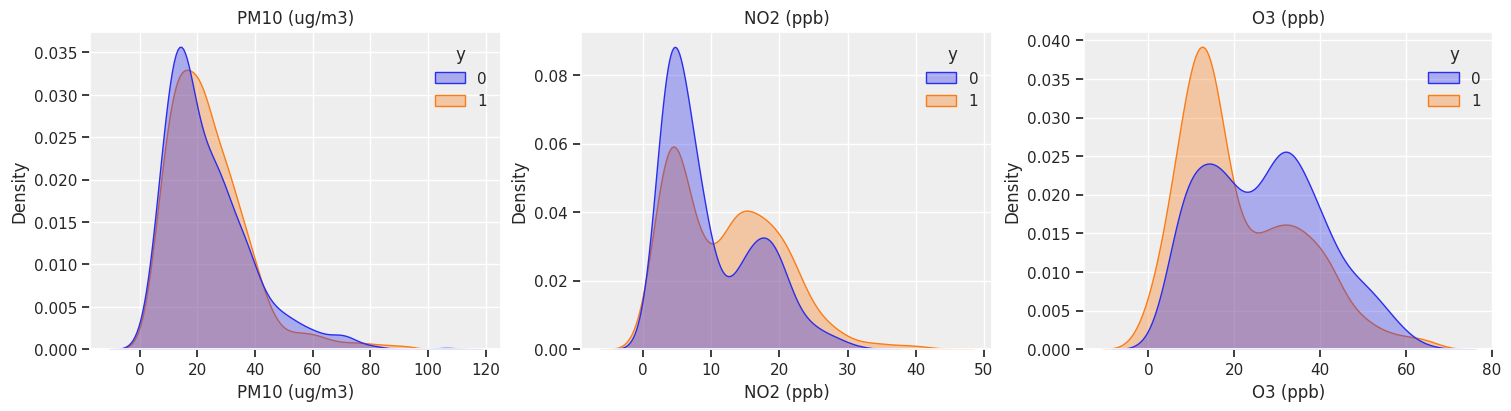

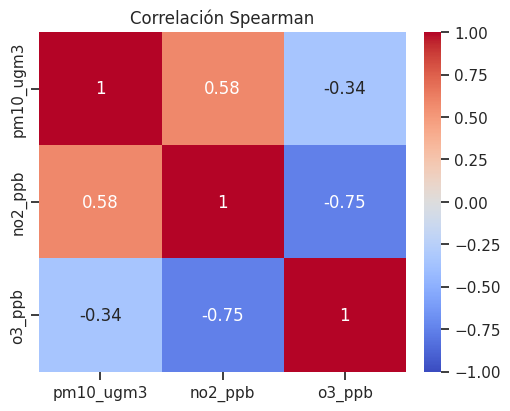

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for ax, col in zip(axes, COVARIATES):
    sns.kdeplot(
        data=df,
        x=col,
        hue="y",
        common_norm=False,
        fill=True,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(COVARIATE_LABELS[col])
    ax.set_xlabel(COVARIATE_LABELS[col])

plt.savefig(OUTPUT_DIR / "02_real_covariate_distributions.png", dpi=180)
plt.show()


corr = df[COVARIATES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

sns.heatmap(
    corr,
    annot=True,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    ax=ax,
)

ax.set_title("Correlación Spearman")

plt.savefig(OUTPUT_DIR / "03_real_covariate_correlation.png", dpi=180)
plt.show()


## 3. Estandarización

Ajustamos el modelo en escala estandarizada:

$$x^* = \frac{x - \mu}{\sigma}$$

Luego transformamos la posterior a unidades originales:

$$\beta_k^{orig} = \frac{\beta_k^{std}}{\sigma_k}$$

$$\beta_0^{orig} = \beta_0^{std} - \sum_k \frac{\mu_k}{\sigma_k}\beta_k^{std}$$

In [11]:
means = df[COVARIATES].mean()
stds = df[COVARIATES].std(ddof=1)

X_std = ((df[COVARIATES] - means) / stds).to_numpy()
y_obs = df["y"].astype(int).to_numpy()

scaling_table = pd.DataFrame({
    "covariate": COVARIATES,
    "mean_original": means.values,
    "sd_original": stds.values,
})
display(scaling_table)

assert np.allclose(X_std.mean(axis=0), 0, atol=1e-10)
assert np.allclose(X_std.std(axis=0, ddof=1), 1, atol=1e-10)

,covariate,mean_original,sd_original
0,pm10_ugm3,23.755571,14.406002
1,no2_ppb,11.116394,7.493367
2,o3_ppb,23.923720,14.038911


## 4. Modelo Bayesiano real

Likelihood presence-background:

$$y_i \sim Bernoulli(\psi_i)$$

$$logit(\psi_i) = \beta_0 + \beta_{PM10}PM10_i^* + \beta_{NO2}NO2_i^* + \beta_{O3}O3_i^*$$

Priors débilmente informativos:

$$\beta_k \sim Normal(0,1), \qquad \beta_0 \sim Normal(0,2)$$

In [18]:
import cloudpickle
import arviz as az

REAL_TRACE_PATH = OUTPUT_DIR / "real_trace_pm10_no2_o3.nc"
REAL_TRACE_BACKUP_PATH = OUTPUT_DIR / "real_trace_pm10_no2_o3_backup.pkl"

coords = {
    "covariate": COVARIATES,
    "obs_id": np.arange(len(df)),
}

with pm.Model(coords=coords) as bayesian_pb_model:
    X = pm.Data("X", X_std, dims=("obs_id", "covariate"))

    beta = pm.Normal("beta", mu=0, sigma=1, dims="covariate")
    beta_0 = pm.Normal("beta_0", mu=0, sigma=1)

    eta = pm.Deterministic(
        "eta",
        beta_0 + pm.math.dot(X, beta),
        dims="obs_id",
    )

    psi = pm.Deterministic(
        "psi",
        pm.math.invlogit(eta),
        dims="obs_id",
    )

    obs = pm.Bernoulli(
        "obs",
        p=psi,
        observed=y_obs,
        dims="obs_id",
    )

    real_trace = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": False},
        progressbar=True,
        compute_convergence_checks=False,
    )

real_trace.to_netcdf(REAL_TRACE_PATH)

with open(REAL_TRACE_BACKUP_PATH, "wb") as f:
    cloudpickle.dump(real_trace, f)

print(f"Guardado en: {REAL_TRACE_PATH}")
print(f"Backup guardado en: {REAL_TRACE_BACKUP_PATH}")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, beta_0]


Output()

Sampling 4 chains for 2_000 tune and 20_000 draw iterations (8_000 + 80_000 draws total) took 16302 seconds.


Guardado en: C:\Users\Miguel Camargo\Desktop\PROYECTOBAYESIANA-COPETON\04_bayesian_model\outputs_pm10_no2_o3\real_trace_pm10_no2_o3.nc
Backup guardado en: C:\Users\Miguel Camargo\Desktop\PROYECTOBAYESIANA-COPETON\04_bayesian_model\outputs_pm10_no2_o3\real_trace_pm10_no2_o3_backup.pkl


In [19]:
import cloudpickle
import arviz as az

REAL_TRACE_PATH = OUTPUT_DIR / "real_trace_pm10_no2_o3.nc"
REAL_TRACE_BACKUP_PATH = OUTPUT_DIR / "real_trace_pm10_no2_o3_backup.pkl"

if REAL_TRACE_PATH.exists():
    real_trace = az.from_netcdf(REAL_TRACE_PATH)
    print(f"Cargado desde NetCDF: {REAL_TRACE_PATH}")

elif REAL_TRACE_BACKUP_PATH.exists():
    with open(REAL_TRACE_BACKUP_PATH, "rb") as f:
        real_trace = cloudpickle.load(f)
    print(f"Cargado desde backup pickle: {REAL_TRACE_BACKUP_PATH}")

else:
    raise FileNotFoundError("No encontre ni el .nc ni el backup .pkl del trace real.")


Cargado desde NetCDF: C:\Users\Miguel Camargo\Desktop\PROYECTOBAYESIANA-COPETON\04_bayesian_model\outputs_pm10_no2_o3\real_trace_pm10_no2_o3.nc


In [20]:
az.summary(real_trace, var_names=["beta", "beta_0"], hdi_prob=0.95)


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[pm10_ugm3],-0.280,0.076,-0.430,-0.130,0.000,0.0,49067.0,51510.0,1.0
beta[no2_ppb],0.331,0.104,0.130,0.539,0.001,0.0,39485.0,47148.0,1.0
beta[o3_ppb],-0.263,0.083,-0.422,-0.098,0.000,0.0,45398.0,51389.0,1.0
beta_0,0.194,0.056,0.083,0.303,0.000,0.0,65488.0,53803.0,1.0


## 5. Diagnósticos de convergencia

In [22]:
summary_std = az.summary(real_trace, var_names=["beta", "beta_0"], hdi_prob=0.95)
display(summary_std)

max_rhat = summary_std["r_hat"].max()
min_ess_bulk = summary_std["ess_bulk"].min()
n_divergences = int(real_trace.sample_stats["diverging"].sum().values)

print(f"R-hat máximo: {max_rhat:.4f}")
print(f"ESS bulk mínimo: {min_ess_bulk:.0f}")
print(f"Divergencias: {n_divergences}")

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[pm10_ugm3],-0.280,0.076,-0.430,-0.130,0.000,0.0,49067.0,51510.0,1.0
beta[no2_ppb],0.331,0.104,0.130,0.539,0.001,0.0,39485.0,47148.0,1.0
beta[o3_ppb],-0.263,0.083,-0.422,-0.098,0.000,0.0,45398.0,51389.0,1.0
beta_0,0.194,0.056,0.083,0.303,0.000,0.0,65488.0,53803.0,1.0


R-hat máximo: 1.0000
ESS bulk mínimo: 39485
Divergencias: 0


C:\Users\Miguel Camargo\AppData\Local\Temp\ipykernel_30312\3556042244.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


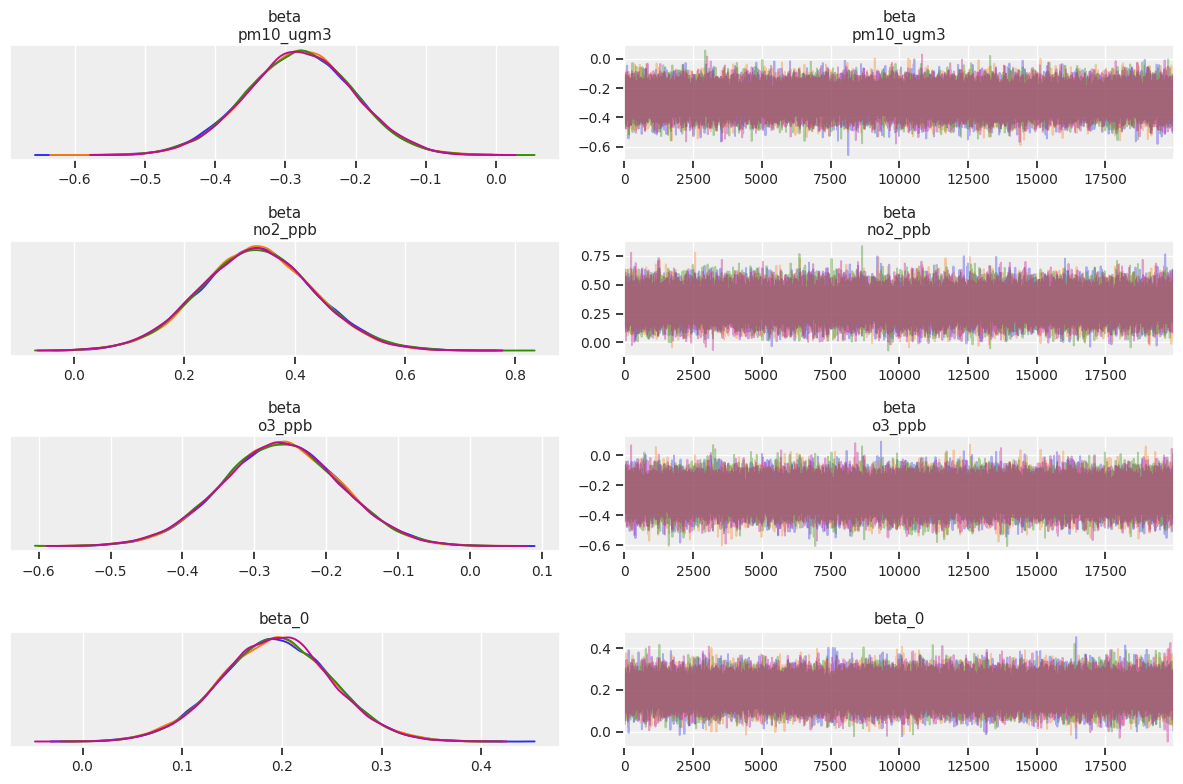

C:\Users\Miguel Camargo\AppData\Local\Temp\ipykernel_30312\3556042244.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


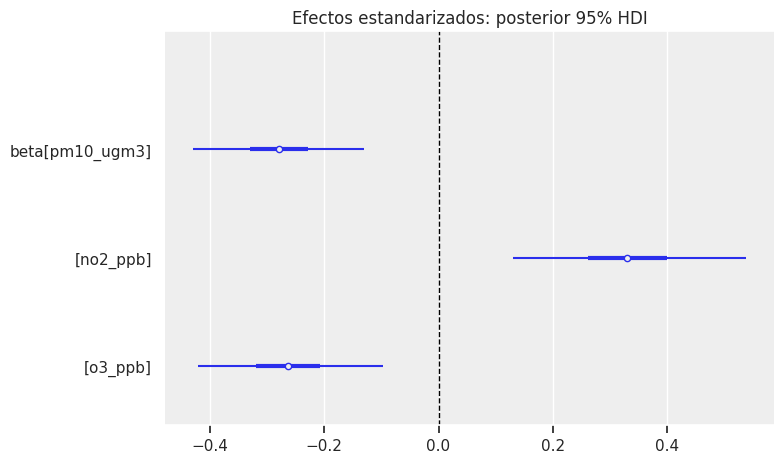

In [23]:
az.plot_trace(real_trace, var_names=["beta", "beta_0"], compact=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_real_trace.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
az.plot_forest(real_trace, var_names=["beta"], combined=True, hdi_prob=0.95, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Efectos estandarizados: posterior 95% HDI")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_real_standardized_effects.png", dpi=180)
plt.show()

## 6. Diagnóstico predictivo presence-background

Este bloque sigue la lógica de regresión logística del notebook de referencia: usamos la media posterior de $\psi$ para revisar qué tan bien separa presencias de puntos de fondo. No debe leerse como una probabilidad absoluta de ocupación.

AUC in-sample presence-background: 0.637
Accuracy con umbral 0.5: 0.573


C:\Users\Miguel Camargo\AppData\Local\Temp\ipykernel_30312\4129498761.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


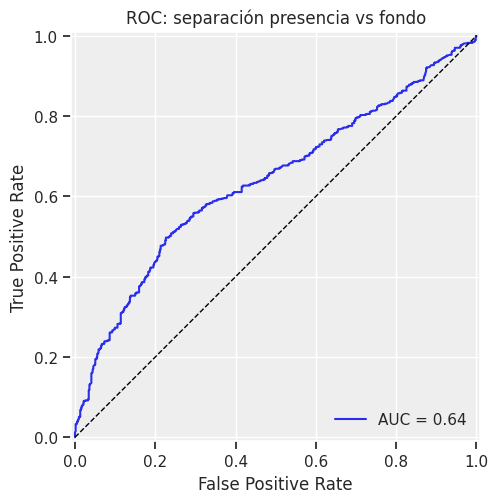

C:\Users\Miguel Camargo\AppData\Local\Temp\ipykernel_30312\4129498761.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


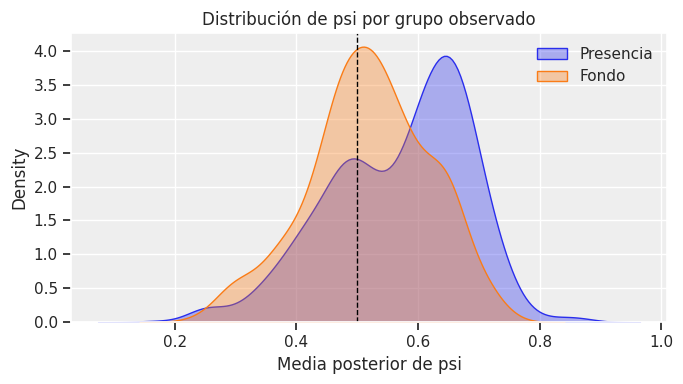

In [24]:
psi_mean = real_trace.posterior["psi"].mean(dim=("chain", "draw")).values
y_pred_05 = (psi_mean >= 0.5).astype(int)

fpr, tpr, thresholds = roc_curve(y_true=y_obs, y_score=psi_mean, pos_label=1)
roc_auc = auc(fpr, tpr)
acc_05 = accuracy_score(y_obs, y_pred_05)

print(f"AUC in-sample presence-background: {roc_auc:.3f}")
print(f"Accuracy con umbral 0.5: {acc_05:.3f}")

fig, ax = plt.subplots(figsize=(5.8, 5.2))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=ax)
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
ax.set_title("ROC: separación presencia vs fondo")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_real_roc_presence_background.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(x=psi_mean[y_obs == 1], label="Presencia", fill=True, alpha=0.35, ax=ax)
sns.kdeplot(x=psi_mean[y_obs == 0], label="Fondo", fill=True, alpha=0.35, ax=ax)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Media posterior de psi")
ax.set_title("Distribución de psi por grupo observado")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_real_psi_by_group.png", dpi=180)
plt.show()

## 7. Posterior desestandarizada

Aquí llevamos cada muestra posterior a la escala original de los contaminantes. Esto permite reportar odds ratios por una unidad física: 1 ug/m3 de PM10, 1 ppb de NO2 y 1 ppb de O3.

In [26]:
def summarize_vector(samples, hdi_prob=0.95):
    hdi = az.hdi(samples, hdi_prob=hdi_prob)
    return {
        "mean": np.mean(samples),
        "sd": np.std(samples, ddof=1),
        "hdi_2.5%": hdi[0],
        "hdi_97.5%": hdi[1],
        "p_gt_0": np.mean(samples > 0),
        "p_lt_0": np.mean(samples < 0),
    }

beta_std = real_trace.posterior["beta"].transpose("chain", "draw", "covariate").values
beta0_std = real_trace.posterior["beta_0"].values

means_np = means.loc[COVARIATES].to_numpy()
stds_np = stds.loc[COVARIATES].to_numpy()

beta_orig = beta_std / stds_np
beta0_orig = beta0_std - np.sum((means_np / stds_np) * beta_std, axis=2)

rows = []
for j, cov in enumerate(COVARIATES):
    std_samples = beta_std[:, :, j].ravel()
    orig_samples = beta_orig[:, :, j].ravel()
    or_std_samples = np.exp(std_samples)
    or_orig_samples = np.exp(orig_samples)
    row = {
        "covariate": cov,
        "label": COVARIATE_LABELS[cov],
        "beta_std_mean": np.mean(std_samples),
        "beta_std_hdi_2.5%": az.hdi(std_samples, hdi_prob=0.95)[0],
        "beta_std_hdi_97.5%": az.hdi(std_samples, hdi_prob=0.95)[1],
        "OR_per_1SD_mean": np.mean(or_std_samples),
        "beta_original_mean": np.mean(orig_samples),
        "beta_original_hdi_2.5%": az.hdi(orig_samples, hdi_prob=0.95)[0],
        "beta_original_hdi_97.5%": az.hdi(orig_samples, hdi_prob=0.95)[1],
        "OR_per_unit_mean": np.mean(or_orig_samples),
        "OR_per_unit_hdi_2.5%": az.hdi(or_orig_samples, hdi_prob=0.95)[0],
        "OR_per_unit_hdi_97.5%": az.hdi(or_orig_samples, hdi_prob=0.95)[1],
        "Pr(beta_original_gt_0)": np.mean(orig_samples > 0),
        "Pr(beta_original_lt_0)": np.mean(orig_samples < 0),
    }
    rows.append(row)

posterior_original = pd.DataFrame(rows)
display(posterior_original)
posterior_original.to_csv(OUTPUT_DIR / "posterior_original_scale_pm10_no2_o3.csv", index=False)

intercept_original_summary = summarize_vector(beta0_orig.ravel())
display(pd.DataFrame([intercept_original_summary], index=["beta_0_original"]))

,covariate,label,beta_std_mean,beta_std_hdi_2.5%,beta_std_hdi_97.5%,OR_per_1SD_mean,beta_original_mean,beta_original_hdi_2.5%,beta_original_hdi_97.5%,OR_per_unit_mean,OR_per_unit_hdi_2.5%,OR_per_unit_hdi_97.5%,Pr(beta_original_gt_0),Pr(beta_original_lt_0)
0,pm10_ugm3,PM10 (ug/m3),-0.279689,-0.429765,-0.129833,0.758222,-0.019415,-0.029832,-0.009012,0.980786,0.970608,0.991028,0.000075,0.999925
1,no2_ppb,NO2 (ppb),0.331313,0.129621,0.538824,1.400366,0.044214,0.017298,0.071907,1.045307,1.017449,1.074555,0.999525,0.000475
2,o3_ppb,O3 (ppb),-0.263184,-0.421535,-0.097802,0.771235,-0.018747,-0.030026,-0.006967,0.981445,0.970420,0.993058,0.000750,0.999250


,mean,sd,hdi_2.5%,hdi_97.5%,p_gt_0,p_lt_0
beta_0_original,0.612234,0.241708,0.143595,1.088211,0.994375,0.005625


C:\Users\Miguel Camargo\AppData\Local\Temp\ipykernel_30312\3739919575.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


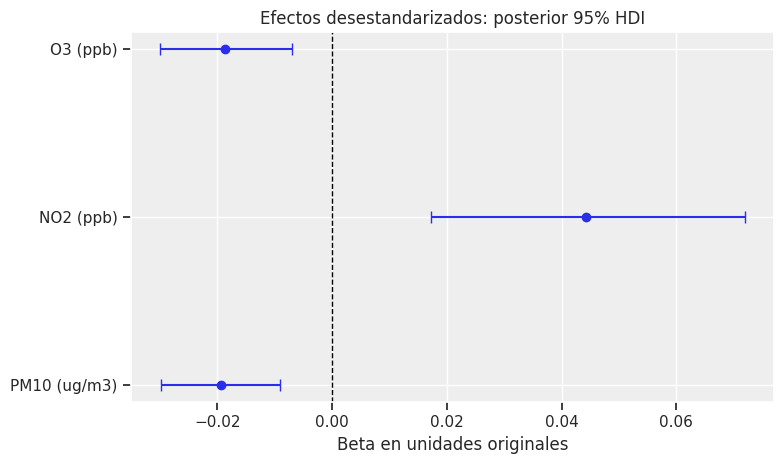

C:\Users\Miguel Camargo\AppData\Local\Temp\ipykernel_30312\3739919575.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


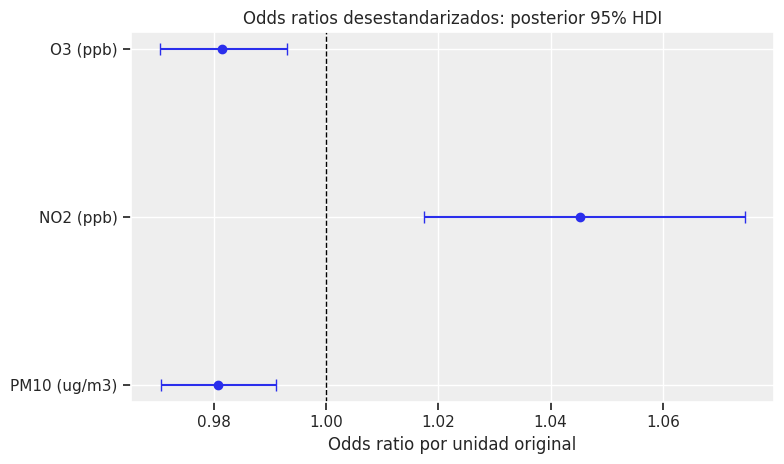

In [27]:
plot_df = posterior_original.copy()

fig, ax = plt.subplots(figsize=(8, 4.8))
ypos = np.arange(len(plot_df))
ax.errorbar(
    plot_df["beta_original_mean"],
    ypos,
    xerr=[
        plot_df["beta_original_mean"] - plot_df["beta_original_hdi_2.5%"],
        plot_df["beta_original_hdi_97.5%"] - plot_df["beta_original_mean"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Beta en unidades originales")
ax.set_title("Efectos desestandarizados: posterior 95% HDI")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_real_original_scale_effects.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(
    plot_df["OR_per_unit_mean"],
    ypos,
    xerr=[
        plot_df["OR_per_unit_mean"] - plot_df["OR_per_unit_hdi_2.5%"],
        plot_df["OR_per_unit_hdi_97.5%"] - plot_df["OR_per_unit_mean"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Odds ratio por unidad original")
ax.set_title("Odds ratios desestandarizados: posterior 95% HDI")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_real_original_scale_odds_ratios.png", dpi=180)
plt.show()

## 8. Interpretación automática de dirección

La tabla siguiente resume la dirección posterior. Para sustentación, conviene frasear los resultados como asociaciones con intensidad relativa de presencia, no como ocupación absoluta.

In [28]:
interpretation = posterior_original[[
    "label",
    "beta_original_mean",
    "beta_original_hdi_2.5%",
    "beta_original_hdi_97.5%",
    "OR_per_unit_mean",
    "OR_per_unit_hdi_2.5%",
    "OR_per_unit_hdi_97.5%",
    "Pr(beta_original_gt_0)",
    "Pr(beta_original_lt_0)",
]].copy()

def direction(row):
    if row["Pr(beta_original_gt_0)"] >= 0.95:
        return "asociación positiva clara"
    if row["Pr(beta_original_lt_0)"] >= 0.95:
        return "asociación negativa clara"
    return "evidencia incierta / compatible con cero"

interpretation["lectura"] = interpretation.apply(direction, axis=1)
display(interpretation)
interpretation.to_csv(OUTPUT_DIR / "interpretacion_posterior_pm10_no2_o3.csv", index=False)

,label,beta_original_mean,beta_original_hdi_2.5%,beta_original_hdi_97.5%,OR_per_unit_mean,OR_per_unit_hdi_2.5%,OR_per_unit_hdi_97.5%,Pr(beta_original_gt_0),Pr(beta_original_lt_0),lectura
0,PM10 (ug/m3),-0.019415,-0.029832,-0.009012,0.980786,0.970608,0.991028,0.000075,0.999925,asociación negativa clara
1,NO2 (ppb),0.044214,0.017298,0.071907,1.045307,1.017449,1.074555,0.999525,0.000475,asociación positiva clara
2,O3 (ppb),-0.018747,-0.030026,-0.006967,0.981445,0.970420,0.993058,0.000750,0.999250,asociación negativa clara


## 9. Cierre metodológico

Recordatorio para la escritura del informe:

- Los puntos de fondo no son ausencias biológicas.
- El intercepto no debe interpretarse como prevalencia real del Copetón.
- Los coeficientes reflejan cambios relativos en la intensidad/idoneidad asociada a las covariables ambientales.
- La estandarización se usa para muestreo; la interpretación ecológica se reporta con la posterior desestandarizada.